# Кластеризация. Домашка

## Совсем простая рекомендательная система

На основе оценок аниме, которые ставят пользователи систем типа [MAL](https://myanimelist.net/), можно строить разные кластеры данных:
- кластеры похожих людей. Похожие значит, что эти люди ставят похожие рейтинги аниме.
- кластеры похожих аниме. Похожие значит что люди оценивают их похоже.
- кластеры похожих жанров. Но похожие не в обычном смысле, а в смысле, что люди которые смотрят жанр А любят смотреть жанр Б.

и т.д.

### Полезная литература

- [Лекция 8. Рекомендательный системы](https://www.youtube.com/watch?v=Te_6TqEhyTI&t=4s).
- [Туториал по рекомендательным системам](http://nbviewer.jupyter.org/urls/gitlab.7bits.it/isiganov/ml-course/raw/master/week05/theory/05-01-clustering.ipynb?inline=false)
- [ODS: Обучение без учителя: PCA и кластеризация](https://habrahabr.ru/company/ods/blog/325654/)
- [Интересные алгоритмы кластеризации, часть первая: Affinity propagation](https://habrahabr.ru/post/321216/) и другие статьи цикла
- [Глава 7: кластеризация и визуализация. К. В. Воронцов](http://www.machinelearning.ru/wiki/images/6/6d/Voron-ML-1.pdf)
- [Документация sklearn.clustering](http://scikit-learn.org/stable/modules/clustering.html)
- [K-Means Clustering - The Math of Intelligence. Siraj Raval](https://www.youtube.com/watch?v=9991JlKnFmk) объяснение с программированием KMeans вручную



In [1]:
from sklearn import datasets
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from tqdm import tqdm
# from tqdm import tqdm_notebook as tqdm # Раскоментируйте если прогресс бар будет странно работать

%matplotlib inline

# Зафиксируем случайность, чтобы у нас получались одинаковые результаты.
np.random.seed(seed=42)

In [2]:
!gdown --id 1o6pJmR4Rz_nuQrrhmEyXjwurLOiIFjG1 #anime
!gdown --id 1Nc3wdpmmTe7wE4K2qtJ2laWe7U0yRsGS #rating

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1o6pJmR4Rz_nuQrrhmEyXjwurLOiIFjG1
To: /content/anime.csv
100% 936k/936k [00:00<00:00, 70.8MB/s]
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Nc3wdpmmTe7wE4K2qtJ2laWe7U0yRsGS
From (redirected): https://drive.google.com/uc?id=1Nc3wdpmmTe7wE4K2qtJ2laWe7U0yRsGS&confirm=t&uuid=b309dce5-a328-4016-986b-ba121607e140
To: /content/rating.csv
100% 111M/111M [00:01<00:00, 67.5MB/s]


In [3]:
anime_path = "anime.csv"
rating_path = "rating.csv"

## Анализ отзывов аниме

Возьмем датасет с рейтингами аниме: https://www.kaggle.com/CooperUnion/anime-recommendations-database  
Кстати, вы можете посмотреть kernels - это jupyter notebooks, в которых другие люди тоже делали что-то с этим датасетом.

```
Anime.csv

anime_id - myanimelist.net's unique id identifying an anime.
name - full name of anime.
genre - comma separated list of genres for this anime.
type - movie, TV, OVA, etc.
episodes - how many episodes in this show. (1 if movie).
rating - average rating out of 10 for this anime.
members - number of community members that are in this anime's "group".


Rating.csv

user_id - non identifiable randomly generated user id.
anime_id - the anime that this user has rated.
rating - rating out of 10 this user has assigned (-1 if the user watched it but didn't assign a rating).
```

In [4]:
colab = False  # True если используте google colab
if colab:
    from google.colab import drive
    drive.mount('/content/drive/')

In [5]:
if colab:
    anime = pd.read_csv('/content/drive/My Drive/Data/anime/anime.csv.zip', index_col='anime_id')
else:
    anime = pd.read_csv(anime_path, index_col='anime_id')
anime.dropna(inplace=True)
print(anime.shape)
anime.head()

(12017, 6)


,name,genre,type,episodes,rating,members
anime_id,,,,,,
32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [6]:
if colab:
    ratings = pd.read_csv('/content/drive/My Drive/Data/anime/rating.csv.zip')
else:
    ratings = pd.read_csv(rating_path)
ratings

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
...,...,...,...
7813732,73515,16512,7
7813733,73515,17187,9
7813734,73515,22145,10
7813735,73516,790,9


Датасет очень большой и грязный. Некоторые действия с этим датасетом будут требовать много оперативной памяти(>6 Гб).

## Подготовка данных

Во первых, в датасете есть много -1. Оценки -1 и 0 на MAL нет.

Здесь -1 означает что человек посмотрел это аниме, но не выставил оценку.

Такие записи из `ratings` стоит выбросить, так как в нашем случае они особо не помогут.

Но и не помешают серьезно. Если хотите оставьте их, только нужно заменить все -1 на 0, так как дальше нам понадобится посчитать среднее, а -1 или 0, в отличие от `np.nan`, повлияют на среднее.

### 1. Избавьтесь от -1

In [7]:
ratings['rating'] = ratings['rating'].replace(-1, np.nan)

## Критерий Шавене (Chauvenet)

[Теория](https://www.youtube.com/watch?v=Fy9pHH3ykPE&list=PLLyuiBK_HOLPfRVN6r9305FKXq1ravbbX)

$$ erfc(\frac{|P_i - mean(P)|}{S_p})  < \frac{1}{2n}$$

$ S_p - отклонение $

Готовой реализации в библиотеках нет, поэтому придется написать самим(но если найдете можете использовать).

### 2. Напишите функцию, которая принимает на вход массив, считает критерий Шавене и возвращает булеву маску.

Функция `erfc` есть в sklearn.

In [8]:
from scipy.special import erfc


def chauvenet(array):
    ###  Ваш код  ###
    # array = array.dropna()

    mean = array.mean()
    std = array.std()
    N = len(array)



    z_scores = np.abs(array - mean) / std

    prob = erfc(z_scores)

    mask = prob < (1 / (2 * N))

    return mask

Для начала давайте посмотрим на таблицу рейтингов.

### 3. Сделайте новую таблицу `count_reviews` где индексами будет `user_id` а значением будет количество просмотренных им аниме.


**Hint** Используйте [groupby](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html) и [count](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.count.html).

In [9]:
###  Ваш код  ###

count_reviews = ratings.groupby('user_id').size().to_frame('records_count')

In [10]:
count_reviews.head()

,records_count
user_id,
1,153
2,3
3,94
4,52
5,467


### 4. Используйте функцию chauvenet и найдите все выбросы.

**Hint:** Так как chauvenet возвращает маску используйте оператор `[]` (подробнее смотрите в 1 теории по pandas и numpy).

**Hint:** Используйте [values](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.values.html).

In [11]:
outlier_users = count_reviews[chauvenet(count_reviews['records_count'].values)]
outlier_users

,records_count
user_id,
17,601
54,834
226,742
271,599
294,675
...,...
73234,812
73286,760
73362,613


### 5. Ответьте на вопросы

#### Кого критерий посчитал выбросом?

#### Почему критерий посчитал их выбросом?

#### Нужна ли им вообще рекомендательная система?


**Ответы:**

Пользователем с большим количеством просмотренных аниме. Примерно от 600

Критерий посчитал их выбросами из-за того, что обычный пользователь просмотрел меньше

Таким пользователям скорее рекомендации не нужна, они сами найдут что посмотреть/посмотрели уже всё, что интересует

In [12]:
bad_user_threshold = outlier_users.min()
bad_user_threshold

,0
records_count,594


Если все было правильно `bad_user_threshold` больше 500.

Нужно выбросить всех людей у которых число просмотренных аниме больше или равно `bad_user_threshold`.

### 6. Переименнуйте столбец из таблицы `count_reviews` в `count_reviews` (он там единственный). Соедините `count_reviews` и `ratings` по столбцу `user_id`. И оставьте в `ratings` только тех кто посмотрел меньше `bad_user_threshold`  

In [13]:
###  Ваш код  ###
count_reviews = count_reviews.rename(columns={'records_count':'count_reviews'})

ratings_new = pd.merge(
    left=ratings,
    right=count_reviews,
    on='user_id',
    how='left'
)

# ratings_new.head()

ratings_new = ratings_new[ratings_new['count_reviews'] < bad_user_threshold.item()]


ratings_new

,user_id,anime_id,rating,count_reviews
0,1,20,NaN,153
1,1,24,NaN,153
2,1,79,NaN,153
3,1,226,NaN,153
4,1,241,NaN,153
...,...,...,...,...
7813732,73515,16512,7.0,196
7813733,73515,17187,9.0,196
7813734,73515,22145,10.0,196
7813735,73516,790,9.0,2


Осталось все равно слишком много пользователей.

### 7. Удалите из таблицы всех юзеров, у которых количество просмотров меньше медианного значения. То есть мы удалим половину юзеров.

Так как они посмотрели слишком мало, чтобы мы на них могли основывать свои советы.

In [14]:
###  Ваш код  ###
ratings_new = ratings_new[ratings_new['count_reviews'] >= count_reviews['count_reviews'].median()]


ratings_new

,user_id,anime_id,rating,count_reviews
0,1,20,NaN,153
1,1,24,NaN,153
2,1,79,NaN,153
3,1,226,NaN,153
4,1,241,NaN,153
...,...,...,...,...
7813730,73515,13659,8.0,196
7813731,73515,14345,7.0,196
7813732,73515,16512,7.0,196
7813733,73515,17187,9.0,196


In [15]:
# Удалим столбец с просмотрами чтобы не мешал.

ratings_new = ratings_new.drop(columns=['count_reviews'])

ratings = ratings_new

In [16]:
ratings

,user_id,anime_id,rating
0,1,20,NaN
1,1,24,NaN
2,1,79,NaN
3,1,226,NaN
4,1,241,NaN
...,...,...,...
7813730,73515,13659,8.0
7813731,73515,14345,7.0
7813732,73515,16512,7.0
7813733,73515,17187,9.0


Теперь рассмотрим таблицу `anime`.


Так же применим критерий шавене.

Искать выбросы стоит по столбцу `rating` или по `members` или по обоим сразу.

### 8. Используйте функцию chauvenet и найдите все выбросы среди аниме. И удалите их.

**Hint** Используйте [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html) и [index](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.index.html)

In [17]:
anime.head()

,name,genre,type,episodes,rating,members
anime_id,,,,,,
32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [18]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12017 entries, 32281 to 26081
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      12017 non-null  object 
 1   genre     12017 non-null  object 
 2   type      12017 non-null  object 
 3   episodes  12017 non-null  object 
 4   rating    12017 non-null  float64
 5   members   12017 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 657.2+ KB


In [19]:
###  Ваш код  ###
outlier_anime_rating = anime[chauvenet(anime['rating'].values)]
outlier_anime_members = anime[chauvenet(anime['members'].values)]

outlier_anime = pd.concat([outlier_anime_rating, outlier_anime_members])
outlier_anime = outlier_anime.drop_duplicates()

outlier_anime

,name,genre,type,episodes,rating,members
anime_id,,,,,,
2792,Panzer Dragoon,"Adventure, Fantasy",OVA,1,3.47,1047
11883,Nendo no Tatakai 2,"Comedy, Fantasy",ONA,1,3.46,1042
29617,Good-by Elvis and USA,"Dementia, Music",Movie,1,3.41,367
11897,Nendo no Tatakai,"Comedy, Fantasy",ONA,1,3.36,1174
32894,Love Bites,Horror,ONA,1,3.33,537
...,...,...,...,...,...,...
9041,IS: Infinite Stratos,"Action, Comedy, Harem, Mecha, Sci-Fi",TV,12,7.12,254543
7593,Kiss x Sis (TV),"Comedy, Ecchi, Harem, Romance, School, Seinen",TV,12,7.09,215361
11285,Black★Rock Shooter (TV),"Action, Drama, School, Slice of Life",TV,8,7.07,198991


In [20]:
anime = anime[~anime.index.isin(outlier_anime.index)]

In [21]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11661 entries, 28977 to 26081
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      11661 non-null  object 
 1   genre     11661 non-null  object 
 2   type      11661 non-null  object 
 3   episodes  11661 non-null  object 
 4   rating    11661 non-null  float64
 5   members   11661 non-null  int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 637.7+ KB


### 9. Ответье на вопросы

#### Что критерий посчитал выбросом?

#### Почему критерий посчитал их выбросом?

#### Можем ли мы как то использовать эти аниме в нашей рекомендательное системе?

**Ответы:**

Критерий считал за выброс очень низкие/высокие значения по members или/и очень высокая/инизкая оценка

Почему это выброс? Это либо что-то очень популярное, либо что-то без статистики(так как не успело её набрать)

Можно попробовать советовать самые популярные и высокоценённые новым пользователям для просмотра

## Кластеризация по жанрам

Данные о жанре хранятся как строка, разделенная запятой `,` . Но нам нужны сами жанры. Придется поколдовать и разделить эту строку на элементы.

In [22]:
from itertools import chain
'''
Нам нужна функция flatmap.
Flatmap получает на вход список, на каждом элементе вызывает функцию f, которая возвращает другой список.
В результате получается список списков. В конфе происходит flatten - уплощение списка скписков в один список.
'''
def flatmap(f, items):
    return chain.from_iterable(map(f, items))

# пример использования
list(flatmap(lambda x: [0, x , x*x], [1,2,3,4,5]))
# Первый шаг: [[0, 1, 1], [0, 2, 4], [0, 3, 9], [0, 4, 16], [0, 5, 25]]

[0, 1, 1, 0, 2, 4, 0, 3, 9, 0, 4, 16, 0, 5, 25]

In [23]:
# создаем функцию, которая просто разбивает строку по символу ", " на подстроки
def genre_splitter(genre_names):
    return genre_names.split(", ")

m_uniq = anime['genre'].unique() # смотрим сколько всего уникальных комбинация genres есть в датасете
print("m_uniq[0:10] = {}\nlen= {}\n".format(m_uniq[0:10], len(m_uniq))) # как видим комбинаций очень много, так как там все композиции

genres = set(flatmap(genre_splitter, m_uniq)) # разбиваем все genres на составные части и генерируем один массив из всех жанров. Строим по массиву множество уникальных жанров

genres = list(genres) # множество превращаем в список
print("Genres={}\nlen={}".format(genres, len(genres)))

m_uniq[0:10] = ['Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen'
 'Comedy, Drama, School, Shounen, Sports' 'Drama, Military, Sci-Fi, Space'
 'Drama, School, Shounen'
 'Adventure, Fantasy, Historical, Mystery, Seinen, Slice of Life, Supernatural'
 'Comedy, Drama, Shounen, Sports'
 'Action, Drama, Historical, Martial Arts, Romance, Samurai'
 'Drama, Fantasy, Shoujo, Slice of Life, Supernatural'
 'Action, Mystery, Supernatural, Vampire'
 'Comedy, Drama, Romance, Shounen']
len= 3135

Genres=['Magic', 'Game', 'Sports', 'Dementia', 'Yaoi', 'Yuri', 'Thriller', 'Sci-Fi', 'Demons', 'Shoujo Ai', 'Supernatural', 'Military', 'Cars', 'Harem', 'Mystery', 'Shoujo', 'Historical', 'Mecha', 'Fantasy', 'Psychological', 'Horror', 'Slice of Life', 'Samurai', 'Comedy', 'Shounen', 'Police', 'Romance', 'Adventure', 'Seinen', 'Vampire', 'Kids', 'Josei', 'Hentai', 'Super Power', 'Parody', 'Shounen Ai', 'Ecchi', 'School', 'Action', 'Drama', 'Space', 'Music', 'Martial Arts']
len=43


### 10. Создадим новую таблицу, где в колонках будет жанр, в строках аниме, а в ячейках 1 если у фильма есть этот жанр и 0 в противном случае.

Такой формат таблиц называтеся one-hot-encoding. Только в нашем случае в каждой строке будет не одна единица, а несколько, так как у аниме как правило несолько жанров.

Уточнение: жанры должны быть индексами столбцов (columns), а id аниме - индексами строк (index)

In [24]:
###  Ваш код  ###

anime_genres = anime[['name']].copy()

for genre in genres:
    anime_genres[genre] = anime['genre'].apply(lambda x: 1 if genre in genre_splitter(x) else 0)

anime_genres.head()

,name,Magic,Game,Sports,Dementia,Yaoi,Yuri,Thriller,Sci-Fi,Demons,...,Super Power,Parody,Shounen Ai,Ecchi,School,Action,Drama,Space,Music,Martial Arts
anime_id,,,,,,,,,,,,,,,,,,,,,
28977,Gintama°,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
9969,Gintama&#039;,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0
32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,0,0,1,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
820,Ginga Eiyuu Densetsu,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,1,0,0
15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,0


Итак, у нас есть следующие таблицы:
- Жанры аниме - в строчках аниме, в столбцах жанр аниме, а в ячейках 0 или 1.
- Рейтинги - в строчках пользователи, в столбцах id аниме и рейтинг

Нужно получить другую таблицу, в которой в строках будут пользователи, а в столбцах жанры аниме. А в ячейках средняя оценка жанра этим пользователем.

Средняя оценка жанра вычисляется следующим образом: берём все отзывы пользователя. Группируем все его отзывы по жанрам и считаем средний рейтинг, который он ставит аниме с данным жанром.

Выполним следущие шаги.

### 11. Соединим две таблицы:<br>
1. жанры по каждому аниме<br>
2. оценки аниме от людей. Кстати, один человек мог посмотреть 1 аниме или 100, но не все!<br>

Получим таблицу, где строк будет N*M штук, где N - количество юзеров и M - количество аниме

In [25]:
###  Ваш код  ###

rates_anime = pd.merge(
    left=anime_genres,
    right=ratings,
    on='anime_id',
    how='inner'
)

rates_anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3836721 entries, 0 to 3836720
Data columns (total 47 columns):
 #   Column         Dtype  
---  ------         -----  
 0   anime_id       int64  
 1   name           object 
 2   Magic          int64  
 3   Game           int64  
 4   Sports         int64  
 5   Dementia       int64  
 6   Yaoi           int64  
 7   Yuri           int64  
 8   Thriller       int64  
 9   Sci-Fi         int64  
 10  Demons         int64  
 11  Shoujo Ai      int64  
 12  Supernatural   int64  
 13  Military       int64  
 14  Cars           int64  
 15  Harem          int64  
 16  Mystery        int64  
 17  Shoujo         int64  
 18  Historical     int64  
 19  Mecha          int64  
 20  Fantasy        int64  
 21  Psychological  int64  
 22  Horror         int64  
 23  Slice of Life  int64  
 24  Samurai        int64  
 25  Comedy         int64  
 26  Shounen        int64  
 27  Police         int64  
 28  Romance        int64  
 29  Adventure     

С такой таблицей `(N*M) * G` вы всё еще не можем работать.  
### 12. Сгруппируем строки по пользователям (колонка `userId`).  В группах посчитаем среднюю оценку на жанр. А если пользователь не смотрел фильм, то поставим ему `-1` в соответсвующую ячейку.
Чтобы посчитать среднее(mean) без учета непросмотренных аниме замените все `0` на `np.NaN`

In [26]:
###  Ваш код  ###

rates_anime_new = rates_anime.copy()
rates_anime_new['rating'] = rates_anime_new['rating'].replace(0, np.nan)
for genre in genres:
    rates_anime_new[genre] = rates_anime_new[genre].replace(0, np.nan) * rates_anime_new['rating']

rates_genre = rates_anime_new.groupby('user_id')[genres].mean()
del rates_anime_new
rates_genre.head()

,Magic,Game,Sports,Dementia,Yaoi,Yuri,Thriller,Sci-Fi,Demons,Shoujo Ai,...,Super Power,Parody,Shounen Ai,Ecchi,School,Action,Drama,Space,Music,Martial Arts
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7.000000,5.000,7.600000,NaN,NaN,NaN,8.000000,6.333333,6.000000,NaN,...,6.600000,NaN,NaN,6.000000,7.250000,6.571429,6.866667,NaN,NaN,6.000000
5,4.375000,4.000,5.888889,NaN,NaN,NaN,7.000000,4.706897,4.166667,1.0,...,4.400000,4.684211,NaN,2.486842,3.505155,4.717172,5.169811,7.25,5.125000,3.772727
7,7.533333,7.375,7.333333,NaN,NaN,NaN,8.166667,7.314815,7.222222,8.0,...,7.714286,8.333333,NaN,6.800000,6.915663,7.227273,7.593750,NaN,6.571429,6.250000
11,6.588235,NaN,9.000000,9.0,NaN,NaN,6.000000,6.700000,7.125000,6.5,...,9.000000,6.500000,4.5,7.333333,6.571429,7.095238,7.325581,7.00,6.333333,7.000000


Так как некоторые пользователи не смотрели ничего из некоторых жанров, в данных осталось много `np.NaN`
### 13. Заполните все NaN на -1

**Hint** [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html)

In [27]:
###  Ваш код  ###
rates_genre[genres] = rates_genre[genres].replace(np.nan, -1)

rates_genre.head()

,Magic,Game,Sports,Dementia,Yaoi,Yuri,Thriller,Sci-Fi,Demons,Shoujo Ai,...,Super Power,Parody,Shounen Ai,Ecchi,School,Action,Drama,Space,Music,Martial Arts
user_id,,,,,,,,,,,,,,,,,,,,,
1,-1.000000,-1.000,-1.000000,-1.0,-1.0,-1.0,-1.000000,-1.000000,-1.000000,-1.0,...,-1.000000,-1.000000,-1.0,-1.000000,-1.000000,-1.000000,-1.000000,-1.00,-1.000000,-1.000000
3,7.000000,5.000,7.600000,-1.0,-1.0,-1.0,8.000000,6.333333,6.000000,-1.0,...,6.600000,-1.000000,-1.0,6.000000,7.250000,6.571429,6.866667,-1.00,-1.000000,6.000000
5,4.375000,4.000,5.888889,-1.0,-1.0,-1.0,7.000000,4.706897,4.166667,1.0,...,4.400000,4.684211,-1.0,2.486842,3.505155,4.717172,5.169811,7.25,5.125000,3.772727
7,7.533333,7.375,7.333333,-1.0,-1.0,-1.0,8.166667,7.314815,7.222222,8.0,...,7.714286,8.333333,-1.0,6.800000,6.915663,7.227273,7.593750,-1.00,6.571429,6.250000
11,6.588235,-1.000,9.000000,9.0,-1.0,-1.0,6.000000,6.700000,7.125000,6.5,...,9.000000,6.500000,4.5,7.333333,6.571429,7.095238,7.325581,7.00,6.333333,7.000000


Прежде чем начать обучать kMeans...

### 14. Отмасштабируйте признаки.

Как мы знаем по лекции, метрическим алгоритмам, одним из которых и является kMeans, лучше подавать на вход данные одного масштаба.  Этим и занимается метод MinMaxScaler из sklearn.

[Документация](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)

Алгоритм его работы:
```
X_std = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))
X_scaled = X_std * (max - min) + min
```

In [28]:
###  Ваш код  ###

scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(rates_genre[genres])

rates_genre[genres] = scaled_values

rates_genre.head()

,Magic,Game,Sports,Dementia,Yaoi,Yuri,Thriller,Sci-Fi,Demons,Shoujo Ai,...,Super Power,Parody,Shounen Ai,Ecchi,School,Action,Drama,Space,Music,Martial Arts
user_id,,,,,,,,,,,,,,,,,,,,,
1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.727273,0.545455,0.781818,0.000000,0.0,0.0,0.818182,0.666667,0.636364,0.000000,...,0.690909,0.000000,0.0,0.636364,0.750000,0.688312,0.715152,0.000000,0.000000,0.636364
5,0.488636,0.454545,0.626263,0.000000,0.0,0.0,0.727273,0.518809,0.469697,0.181818,...,0.490909,0.516746,0.0,0.316986,0.409560,0.519743,0.560892,0.750000,0.556818,0.433884
7,0.775758,0.761364,0.757576,0.000000,0.0,0.0,0.833333,0.755892,0.747475,0.818182,...,0.792208,0.848485,0.0,0.709091,0.719606,0.747934,0.781250,0.000000,0.688312,0.659091
11,0.689840,0.000000,0.909091,0.909091,0.0,0.0,0.636364,0.700000,0.738636,0.681818,...,0.909091,0.681818,0.5,0.757576,0.688312,0.735931,0.756871,0.727273,0.666667,0.727273


### 15.Натренируйте kMeans с 10 кластерами на полученных данных

In [29]:
### Ваш код ###

kmeans = KMeans(n_clusters=10, random_state=42)

cluster_labels = kmeans.fit_predict(rates_genre)

rates_genre['cluster_label'] = cluster_labels

### 16. Нарисуйте на графике центры кластеров нашего датасета оценок фильмов.

В нем будет 10 строчек - 10 кластеров. И 43 столбцов - 43 жанров фильмов.

Из графика мы поймем какие жанры обычно смотрят вместе. По сути мы получили кластеры предпочтений людей.

**Hint** [Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html)

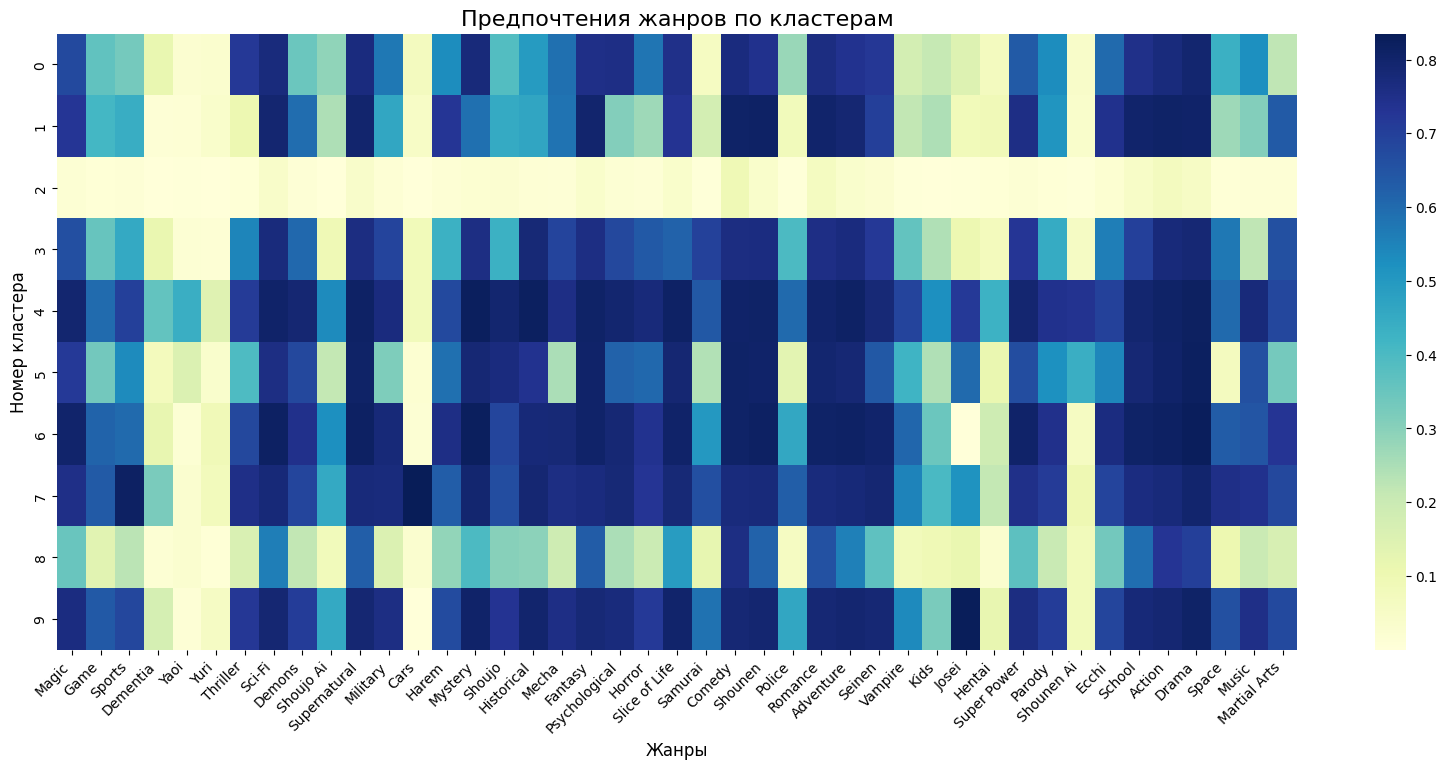

In [30]:
###  Ваш код  ###

cluster_centers = rates_genre.groupby('cluster_label')[genres].mean()

plt.figure(figsize=(20, 8))
sns.heatmap(cluster_centers, cmap="YlGnBu", annot=False, fmt=".2f")
plt.title('Предпочтения жанров по кластерам', fontsize=16)
plt.ylabel('Номер кластера', fontsize=12)
plt.xlabel('Жанры', fontsize=12)


plt.xticks(rotation=45, ha='right')


plt.show()

# Как выбрать нужное число кластеров

Такие методы как KMeans, Spectral clustering, Ward hierarchical clustering, Agglomerative clustering требуют количество кластеров как параметр. Это так называемый гипер-параметр, и его должен подбирать человек. Но на что человеку опираться при выборе? На некоторый функционал "качества"!

Вспомним идею кластеризации:
- минимизация внутрикластерного расстояния
- максимизация межкластерного расстояния

Другими словами - кучки кучнее и дальше друг от друга.

Логично, что мы хотим, чтобы точки распологались кучно возле центров своих кластеров. Но вот незадача: минимум такого функционала будет достигаться тогда, когда кластеров столько же, сколько и точек (то есть каждая точка – это кластер из одного элемента). Для решения этого вопроса (выбора числа кластеров) часто пользуются такой эвристикой: выбирают то число кластеров, начиная с которого описанный функционал $ J(C) $ падает "уже не так быстро". Или более формально: $$ D(k) = \frac{|J(C_k) - J(C_{k+1})|}{|J(C_{k-1}) - J(C_k)|}  \rightarrow \min\limits_k $$

Где, в случае kMeans $$ J(C) = \sum_{k=1}^K\sum_{i~\in~C_k} ||x_i - \mu_k|| \rightarrow \min\limits_C,$$ - сумма квадратов расстояний от точек до центроидов кластеров, к которым они относятся

#### Эта ячейка может выполнятся долго!

100%|██████████| 29/29 [00:28<00:00,  1.04it/s]


Text(0, 0.5, '$J(C_k)$')

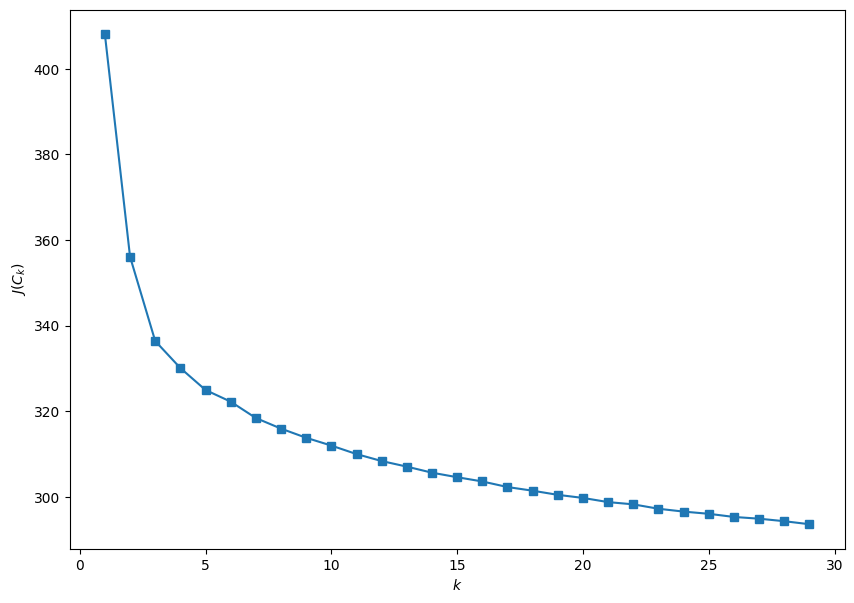

In [38]:
inertia = []
N = 30
for k in tqdm(range(1, N)):
    kmeans = KMeans(n_clusters=k).fit(rates_genre.drop(columns=['cluster_label']))
    inertia.append(np.sqrt(kmeans.inertia_))
plt.figure(figsize=(10,7))
plt.plot(range(1, N), inertia, marker='s');
plt.xlabel('$k$')
plt.ylabel('$J(C_k)$')

## Коэффициент силуэта

Данный коэффициент не предполагает знания истинных меток объектов, и позволяет оценить качество кластеризации, используя только саму (неразмеченную) выборку и результат кластеризации.

Сначала силуэт определяется отдельно для каждого объекта. Обозначим через $a$ - среднее расстояние от данного объекта до объектов из того же кластера, через $b$ - среднее расстояние от данного объекта до объектов из ближайшего кластера (отличного от того, в котором лежит сам объект). Тогда силуэтом данного объекта называется величина: $$s = \frac{b - a}{\max(a, b)}.$$ Силуэтом выборки называется средняя величина силуэта объектов данной выборки. Таким образом, силуэт показывает, насколько среднее расстояние до объектов своего кластера отличается от среднего расстояния до объектов других кластеров. Данная величина лежит в диапазоне $[-1, 1]$. Значения, близкие к -1, соответствуют плохим (разрозненным) кластеризациям, значения, близкие к нулю, говорят о том, что кластеры пересекаются и накладываются друг на друга, значения, близкие к 1, соответствуют "плотным" четко выделенным кластерам. Таким образом, чем больше силуэт, тем более четко выделены кластеры, и они представляют собой компактные, плотно сгруппированные облака точек.

С помощью силуэта можно выбирать оптимальное число кластеров $k$ (если оно заранее неизвестно) - выбирается число кластеров, максимизирующее значение силуэта. В отличие от предыдущих метрик, силуэт зависит от формы кластеров, и достигает больших значений на более выпуклых кластерах, получаемых с помощью алгоритмов, основанных на восстановлении плотности распределения.

#### Эта ячейка может выполняться долго!

In [32]:
from sklearn.metrics import silhouette_score, silhouette_samples

def draw_sil_score(X, range_n_clusters=[2, 3, 4, 5, 6, 10, 12, 13, 20]):
    scores = []
    for n_clusters in tqdm(range_n_clusters):
        clusterer = KMeans(n_clusters=n_clusters, random_state=10)
        cluster_labels = clusterer.fit_predict(X)
        silhouette_avg = silhouette_score(X, cluster_labels)
        scores.append(silhouette_avg)
    plt.plot(range_n_clusters, scores)
    return range_n_clusters[np.argmax(scores)]

100%|██████████| 28/28 [09:06<00:00, 19.52s/it]


2

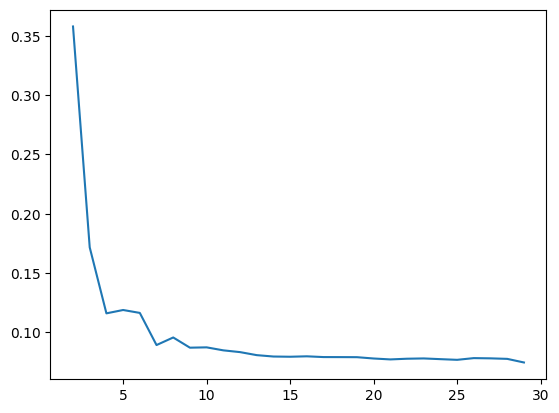

In [33]:
draw_sil_score(scaler.fit_transform(rates_genre.drop(columns=['cluster_label'])), range(2, 30))

### 17. Выберите количество кластеров `k` по методам выше. Натренируйте kMeans и снова нарисуйте heatmap.

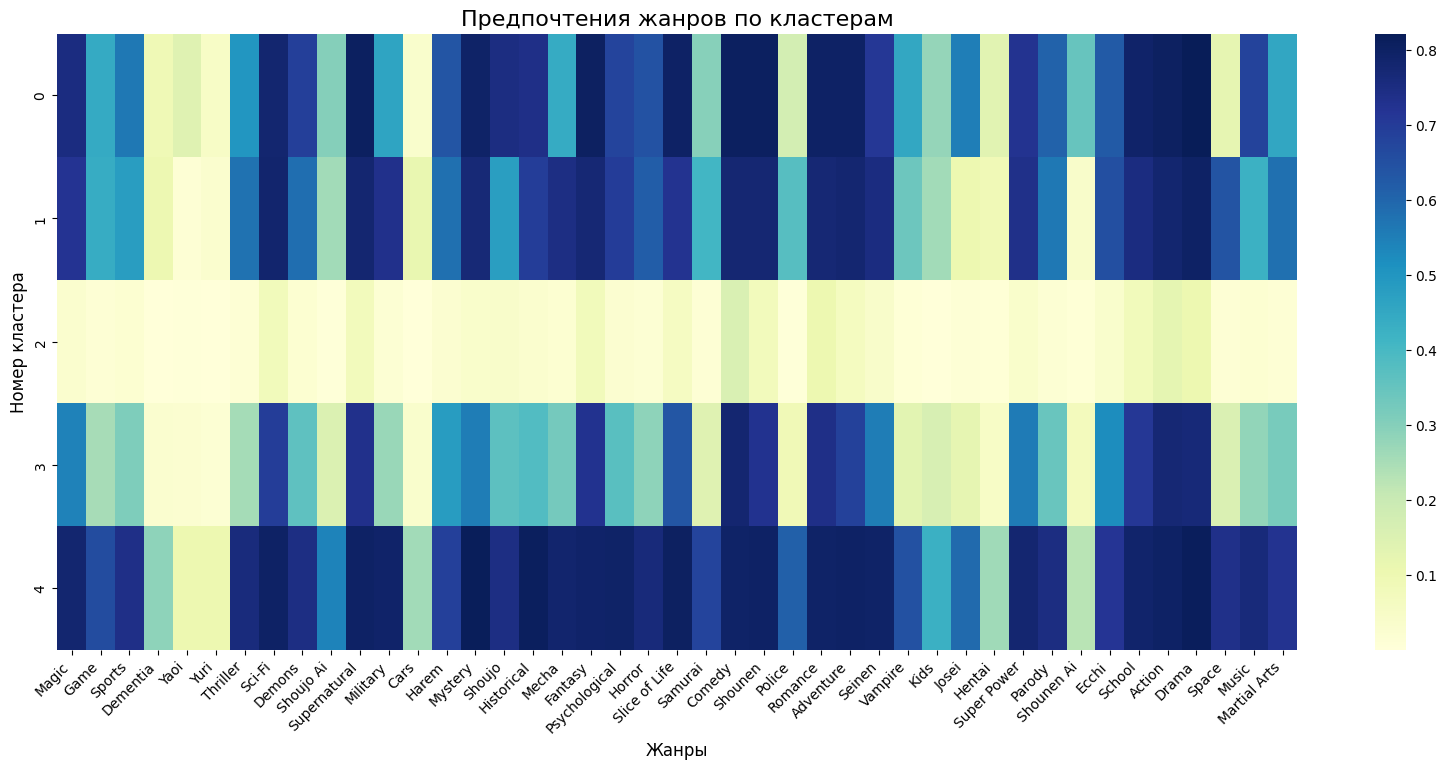

In [34]:
###  Ваш код  ###
# допустим пусть k=5
kmeans = KMeans(n_clusters=5, random_state=42)

cluster_labels = kmeans.fit_predict(rates_genre.drop(columns=['cluster_label']))

rates_genre['cluster_label'] = cluster_labels


cluster_centers = rates_genre.groupby('cluster_label')[genres].mean()

plt.figure(figsize=(20, 8))
sns.heatmap(cluster_centers, cmap="YlGnBu", annot=False, fmt=".2f")
plt.title('Предпочтения жанров по кластерам', fontsize=16)
plt.ylabel('Номер кластера', fontsize=12)
plt.xlabel('Жанры', fontsize=12)


plt.xticks(rotation=45, ha='right')


plt.show()

In [35]:
rates_genre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35708 entries, 1 to 73515
Data columns (total 44 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Magic          35708 non-null  float64
 1   Game           35708 non-null  float64
 2   Sports         35708 non-null  float64
 3   Dementia       35708 non-null  float64
 4   Yaoi           35708 non-null  float64
 5   Yuri           35708 non-null  float64
 6   Thriller       35708 non-null  float64
 7   Sci-Fi         35708 non-null  float64
 8   Demons         35708 non-null  float64
 9   Shoujo Ai      35708 non-null  float64
 10  Supernatural   35708 non-null  float64
 11  Military       35708 non-null  float64
 12  Cars           35708 non-null  float64
 13  Harem          35708 non-null  float64
 14  Mystery        35708 non-null  float64
 15  Shoujo         35708 non-null  float64
 16  Historical     35708 non-null  float64
 17  Mecha          35708 non-null  float64
 18  Fantasy    

### 18. Порекомендуйте что-нибудь абстрактному пользователю.
Это можно сделать разными способами. Как это сделать подумайте сами.

Если затрудняетесь реализовать это в коде, распишите словами как вы бы это сделали.

Возможные варианты решения:
 * в каждом кластере отсортировать жанры по тому, насколько жанр важен.
 * взять каждый кластер -> получить все аниме, которые смотрят в этом кластере -> отсортировать по рейтину.



In [36]:
###  Ваш код или рассуждение или все вместе ###



1.   Собрать данные пользователя
2.   Отнести пользователя к одному из кластеров
3.   Отсортировать по рейтингу аниме в этом кластере
4. Исключить просмотренные пользователям аниме
5. Рекомендовать оставшиеся



### Extra. Попробуйте как-нибудь улучшить эту рекомендашку. Приведите код или рассуждения на эту тему.

Если писать код, то можно:
 * каждому жанру присвоить свой вес, так как одних жанров сильно много и у них разная смысловая нагрузка. Комедии и экшн встречаются очень часто и врядли кто-то только из-за этих жанров будет смотреть аниме.
 * предсказывать не по жанрам, а по аниме. Там получится очень большая размерность, так как нужно сделать one-hot-encoding по аниме, но может это даст лучше результат(спойлер: нет). (И для этого надо сделать 4 join'а, что, возможно, убьет ваш компьютер или/и мозг)

In [37]:
###  Ваш код или рассуждение или все вместе ###